In [148]:
from pylab import *
import numpy as np
import os
from scipy import interpolate
from IPython import display
import models as wedge
import matplotlib.pyplot as plt
import pandas as pd

In [131]:
planet7_out1 = 'out/planet7_1/'
planet7_1 = wedge.load_model(planet7_out1)
mtut.m.print_params()

directory exists - will overwrite current model if you write to it!
Loading from model directory:/Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_1/
writing amr_grid.inp
Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/models/templates/wavelength_micron.inp
Writing /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_1/wavelength_micron.inp
Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_1/wavelength_micron.inp


In [139]:
#Initializing a new model

planet7_out2 = 'out/planet7_2/'

planet7_params = planet7_1.m.print_params()
planet7_2 = wedge.initialize_model(planet7_params, planet7_out2)
# planet7_2.m.print_params()


directory exists - will overwrite current model if you write to it!
Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_2/wavelength_micron.inp
Assigned model directory:/Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_2/


In [143]:
wedge.write_opacities(planet7_2.m,ndust=2,update=False)

Running optool to generate new opacities


....................
....................
Writing dust opacity output to file:  /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_2/dustkappa_dust-1.inp
....................
.......

Running optool to generate new opacities


............

updating dustopac.inp


.
Writing dust opacity output to file:  /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_2/dustkappa_dust-2.inp


In [145]:
wedge.prep_thermal_transfer(planet7_1)
# wedge.overwrite_model(mtut2)

Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_1/wavelength_micron.inp
Writing /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_1/wavelength_micron.inp
Writing stars.inp
writing dust_density.inp
writing external_source.inp
updating radmc3d.inp


0

In [147]:
wedge.prep_thermal_transfer(planet7_2)

Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_2/wavelength_micron.inp
Writing /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/planet7_2/wavelength_micron.inp
Writing stars.inp
writing dust_density.inp
writing external_source.inp
updating radmc3d.inp


0

In [153]:
wedge.do_thermal_transfer(planet7_2, n=8)

  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github                     
             https://github.com/dullemond/radmc3d-2.0            
                                                                 
       

In [10]:
data = pd.read_csv('/Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/DiskLibrary/PP7-Surveys_2022-10-19_PPVII_website.csv')

In [37]:
Mstar = data.loc[:,'Mstar_PPVII']
Macc = data.loc[:, 'logMacc_PPVII']
Mdust = data.loc[:, 'Standardized_Mdust_Mearth']



0       0.610
1       0.291
2     -99.000
3     -99.000
4       0.087
        ...  
886   -99.000
887   -99.000
888   -99.000
889   -99.000
890   -99.000
Name: Mstar_PPVII, Length: 891, dtype: float64

In [27]:
data.head()

,Region,Source,2MASS/SSTc2d,RA,Dec,EDR3_plx,EDR3_err_plx,EDR3_dist_pc,EDR3_RUWE,EDR3_Dist_PPVII,...,Mstar_B15_xs_DR3,logMacc_B15_xs_DR3,Mstar_S00_xs_DR3,logMacc_S00_xs_DR3,Mstar_Fei_xs_DR3,logMacc_Fei_xs_DR3,Mstar_PPVII,logMacc_PPVII,notes_Macc_PPVII,dist_PPVII
0,Lupus,Sz65,J15392776-3446171,39:27.8,-34:46:17.577,6.5159,0.0253,153.47,1.417,153.47,...,0.661,-9.516,0.7250,-9.556,0.61,-9.48,0.610,-9.480,<,153.47
1,Lupus,Sz66,J15392828-3446180,39:28.3,-34:46:18.450,6.4134,0.0269,155.92,1.2,155.92,...,0.291,-8.508,0.3125,-8.538,0.31,-8.54,0.291,-8.508,--,155.92
2,Lupus,J15430131-3409153,J15430131-3409153,43:01.3,-34:09:15.400,--,--,--,--,158.00,...,-99.000,--,-99.0000,--,-99.00,-99.00,-99.000,-99.000,--,-99.00
3,Lupus,J15430227-3444059,J15430227-3444059,43:02.3,-34:44:06.200,-0.0997,0.2261,-10030.09,1.018,158.00,...,-99.000,--,-99.0000,--,-99.00,-99.00,-99.000,-99.000,--,-99.00
4,Lupus,J15445789-3423392,J15445789-3423392,44:57.9,-34:23:39.500,6.4956,0.0772,153.95,1.201,153.95,...,0.087,-10.68,0.1000,-10.74,0.09,-10.70,0.087,-10.680,--,153.95


## Starting Work on fiducial data analysis

In [16]:
fid1_params = wedge.new_model('fiducial_1T')
fid1_out = 'out/fid_analysis/'
fid1_m = wedge.initialize_model(fid1_params, fid1_out)

directory exists - will overwrite current model if you write to it!
Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/wavelength_micron.inp
Assigned model directory:/Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/


In [18]:
fid1_m.m.print_params()

{'Ms': 0.2,
 'Rs': 3.0,
 'Ts': 3485,
 'accrate': 8.5e-09,
 'f': 0.01,
 'xmodel': None,
 'Mdisk': 0.2,
 'Mfrac': [0.005, 0.005],
 'R0': [1, 1],
 'H0': [1, 0.2],
 'p': [-1, -1],
 'Rdisk': [175, 175],
 'Tfac': 1,
 'q': 0.5,
 'hydro': [None, None, None],
 'Min': 0,
 'Rc': 90,
 'rho_amb': 1e-25,
 'rho_0': 3e-22,
 'theta_min': 25,
 'exf': 0.25,
 'Rmax': 15000.0,
 'd2g': 0.01,
 'shock': False,
 'nstreams': 1,
 'stream_frac': 1,
 'N': [180, 90, 48],
 'min': [0.1, 0.19634954084936207, 0],
 'max': [400, 1.5707963267948966, 6.283185307179586],
 'spacing': ['log', 'lin', 'lin'],
 'rho_si': 3.1518,
 'amin_chem': 0.06,
 'amax_ism': 1.0,
 'amin': [0.005, 0.005],
 'amax': [1, 1000.0],
 'apow': [3.5, 3.5],
 'cr_model': 'ssx',
 'zetacr': 1.3e-17,
 'G0': 1,
 'viscous_heating': False,
 'fLya': 0.0001,
 'xray': True}

In [31]:
wedge.prep_thermal_transfer(fid1_m)

Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/wavelength_micron.inp
Writing /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/wavelength_micron.inp
Writing stars.inp
writing dust_density.inp
Running optool to generate new opacities


....................
....................
Writing dust opacity output to file:  /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/dustkappa_dust-1.inp
....................
.......

Running optool to generate new opacities


............

updating dustopac.inp
writing external_source.inp
updating radmc3d.inp


.
Writing dust opacity output to file:  /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/dustkappa_dust-2.inp


0

In [32]:
wedge.do_thermal_transfer(fid1_m)

  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github                     
             https://github.com/dullemond/radmc3d-2.0            
                                                                 
       

In [150]:
fid1_m.read_rho()
fid1_m.read_Tdust()
print('Temperature data is stored in m1.T with keys: ', fid1_m.T.keys())
print('Density data is stored in m1.rho with keys:', fid1_m.rho.keys())

Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/dust_density.inp
Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid_analysis/dust_temperature.dat
Temperature data is stored in m1.T with keys:  dict_keys(['dust'])
Density data is stored in m1.rho with keys: dict_keys(['dust1', 'dust2', 'gas'])


In [154]:
fid1_T_components = np.array(fid1_m.T['dust'])

fid1_rho_small_components = np.array(fid1_m.rho['dust1'])
fid1_rho_big_components = np.array(fid1_m.rho['dust2'])
fid1_rho_gas_components = np.array(fid1_m.rho['gas'])


In [156]:
np.shape(fid1_rho_big_components)

(180, 90, 48)

In [158]:
fid1_T_components_r = fid1_T_components[:,-1,-1]
fid1_T_components_th = fid1_T_components[-1,:,-1]
fid1_T_components_phi = fid1_T_components[-1,-1,:]

fid1_rho_small_components_r = fid1_rho_small_components[:,-1,-1]
fid1_rho_small_components_th = fid1_rho_small_components[-1,:,-1]
fid1_rho_small_components_phi = fid1_rho_small_components[-1,-1,:]

fid1_rho_big_components_r = fid1_rho_big_components[:,-1,-1]
fid1_rho_big_components_th = fid1_rho_big_components[-1,:,-1]
fid1_rho_big_components_phi = fid1_rho_big_components[-1,-1,:]

fid1_rho_gas_components_r = fid1_rho_gas_components[:,-1,-1]
fid1_rho_gas_components_th = fid1_rho_gas_components[-1,:,-1]
fid1_rho_gas_components_phi = fid1_rho_gas_components[-1,-1,:]

In [187]:
print(np.shape(fid1_T_components_r), np.shape(fid1_rho_small_components_r))

(180,) (180,)


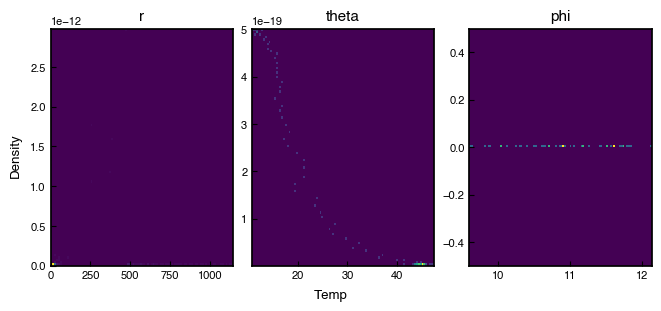

In [521]:
f,ax = plt.subplots(1,3, constrained_layout=True)
f.set_size_inches(6.5,3)
# nbins=100
# plt.figure()
# im = plt.hist2d(fid1_T_components_r, np.log10(fid1_rho_gas_components_r), bins=nbins,cmap='inferno', cmin=0, cmax=10)
# plt.xlabel('Temperature (K)')
# plt.ylabel('Density - gas ($log(gcm^{-3})$)')
# plt.colorbar(im, ax=ax)



datax_toplot = [fid1_T_components_r, fid1_T_components_th, fid1_T_components_phi]
datay_toplot = [fid1_rho_small_components_r, fid1_rho_small_components_th, fid1_rho_small_components_phi]
title_toplot = [r'r',r'theta',r'phi']

for a,datax,datay,titles in zip(ax,datax_toplot, datay_toplot,title_toplot):
    im = a.hist2d(datax, datay,bins=100)
    a.set_title(titles)
    f.supxlabel('Temp')
    f.supylabel('Density')

In [339]:
#DONT SEPARATE BY COMPONENTS AND GET HISTOGRAM FOR EVERYTHING!!
# plt.hist2d(fid1_T_components, np.log10(fid1_rho_gas_components), bins=nbins,cmap='inferno')

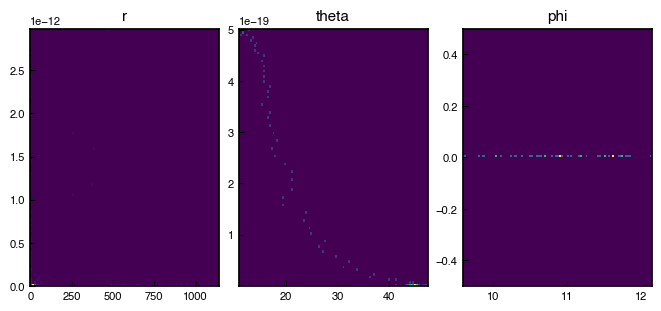

In [397]:
f,ax = plt.subplots(1,3, constrained_layout=True)
f.set_size_inches(6.5,3)


datax_toplot = [fid1_T_components_r, fid1_T_components_th, fid1_T_components_phi]
datay_toplot = [fid1_rho_small_components_r, fid1_rho_small_components_th, fid1_rho_small_components_phi]
title_toplot = [r'r',r'theta',r'phi']

# cbar_r = 
# cbar_th = 
# cbar_phi = 
# cbar_toplot = [cbar_r,cbar_th,cbar_phi]

colors = plt.colormaps.get_cmap('plasma')

for a,datax,datay,titles in zip(ax,datax_toplot, datay_toplot,title_toplot):
    im = a.hist2d(datax, datay,bins=100)
    im
    a.set_title(titles)

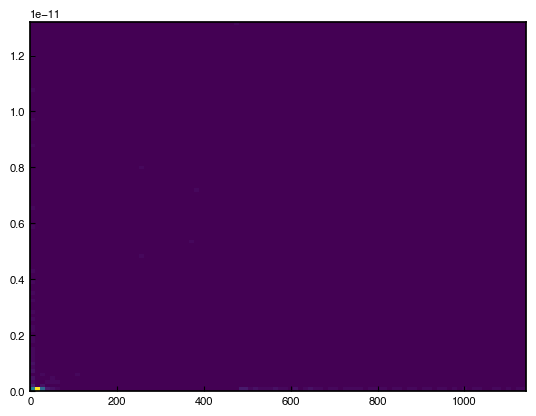

In [493]:
datax  = fid1_T_components_r
datay = fid1_rho_big_components_r


# nbins = 100
# minbin = 0
# maxbin = 10
# arg = np.linspace(minbin, maxbin, nbins)
# cmap = plt.colormaps.get_cmap(arg)

nbins = 100
minbin = 0.
maxbin = 1.

# data = np.random.normal(size=10000)
arg = np.linspace(minbin, maxbin, nbins)

cmap = plt.colormaps.get_cmap('plasma')
# norm = mpl.colors.Normalize(vmin=data.min(), vmax=data.max())
colors = cmap(bins)


plt.hist2d(datax,datay,bins=nbins)
plt.show()

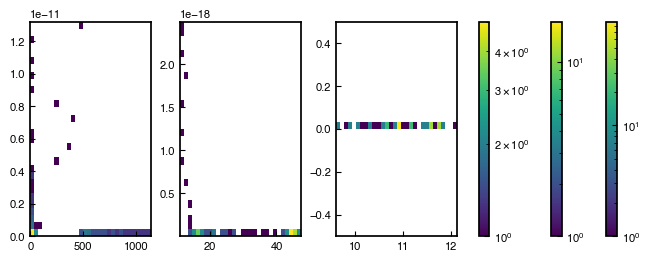

In [186]:
##SUCCESSFUL COLOR BAR (1 PLOT EXAMPLE)

nbins=30
from matplotlib.colors import LogNorm

f, ax = plt.subplots(1,3, constrained_layout=True)
f.set_size_inches(6.5,2.5)

h = ax[0].hist2d(fid1_T_components_r, fid1_rho_big_components_r, bins=nbins, norm=LogNorm())
h2 = ax[1].hist2d(fid1_T_components_th, fid1_rho_big_components_th, bins=nbins, norm=LogNorm())
h3 = ax[2].hist2d(fid1_T_components_phi, fid1_rho_big_components_phi, bins=nbins, norm=LogNorm())
f.colorbar(h[3], ax=ax)
f.colorbar(h2[3], ax=ax)
f.colorbar(h3[3],ax=ax)

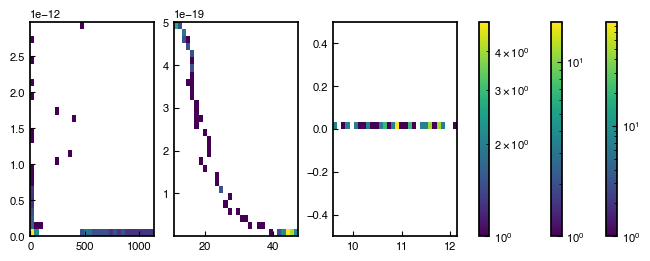

In [551]:
nbins=30

f, ax = plt.subplots(1,3, constrained_layout=True)
f.set_size_inches(6.5,2.5)

h = ax[0].hist2d(fid1_T_components_r, fid1_rho_small_components_r, bins=nbins, norm=LogNorm())
h2 = ax[1].hist2d(fid1_T_components_th, fid1_rho_small_components_th, bins=nbins, norm=LogNorm())
h3 = ax[2].hist2d(fid1_T_components_phi, fid1_rho_small_components_phi, bins=nbins, norm=LogNorm())
f.colorbar(h[3], ax=ax)
f.colorbar(h2[3], ax=ax)
f.colorbar(h3[3],ax=ax)

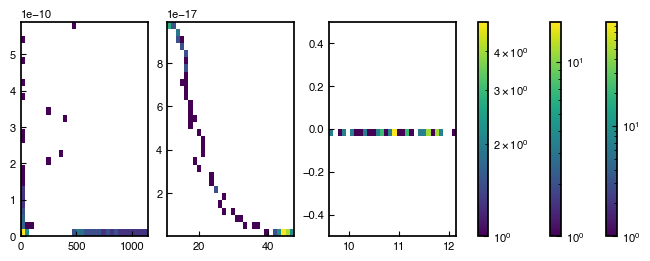

In [553]:
nbins=30

f, ax = plt.subplots(1,3, constrained_layout=True)
f.set_size_inches(6.5,2.5)

h = ax[0].hist2d(fid1_T_components_r, fid1_rho_gas_components_r, bins=nbins, norm=LogNorm())
h2 = ax[1].hist2d(fid1_T_components_th, fid1_rho_gas_components_th, bins=nbins, norm=LogNorm())
h3 = ax[2].hist2d(fid1_T_components_phi, fid1_rho_gas_components_phi, bins=nbins, norm=LogNorm())
f.colorbar(h[3], ax=ax)
f.colorbar(h2[3], ax=ax)
f.colorbar(h3[3],ax=ax)

In [136]:
#fiducial with envelope

# fid2_params = wedge.new_model('fiducial')
fid2_out = 'out/fid2_analysis/'

fid2_m = wedge.load_model(fid2_out)
fid2_m.m.env['Min'] = 1.0e-6
fid2_m.m.env['Ts'] = 3485 #3485
fid2_m.m.env['accrate'] = 8.5e-7 #8.5e-9 

fid2_m.m.print_params()

directory exists - will overwrite current model if you write to it!
Loading from model directory:/Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid2_analysis/
Reading /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid2_analysis/wavelength_micron.inp


{'Ms': 0.2,
 'Rs': 3.0,
 'Ts': 3485,
 'accrate': 8.5e-07,
 'f': 0.01,
 'xmodel': None,
 'Mdisk': 0.2,
 'Mfrac': [0.005, 0.005],
 'R0': [1, 1],
 'H0': [1, 0.2],
 'p': [-1, -1],
 'Rdisk': [175, 175],
 'Tfac': 1,
 'q': 0.5,
 'hydro': [None, None, None],
 'Min': 1e-06,
 'Rc': 90,
 'rho_amb': 1e-25,
 'rho_0': 3e-22,
 'theta_min': 25,
 'exf': 0.25,
 'Rmax': 15000.0,
 'd2g': 0.01,
 'shock': False,
 'nstreams': 1,
 'stream_frac': 1,
 'N': [180, 90, 48],
 'min': [0.1, 0.19634954084936207, 0],
 'max': [400, 1.5707963267948966, 6.283185307179586],
 'spacing': ['log', 'lin', 'lin'],
 'rho_si': 3.1518,
 'amin_chem': 0.06,
 'amax_ism': 1.0,
 'amin': [0.005, 0.005],
 'amax': [1, 1000.0],
 'apow': [3.5, 3.5],
 'cr_model': 'ssx',
 'zetacr': 1.3e-17,
 'G0': 1,
 'viscous_heating': False,
 'fLya': 0.0001,
 'xray': True}

In [138]:
wedge.write_opacities(fid2_m.m,ndust=2,update=False)

updating dustopac.inp


In [140]:
wedge.overwrite_model(fid2_m)

writing amr_grid.inp
Writing /Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/out/fid2_analysis/wavelength_micron.inp
Writing stars.inp
writing dust_density.inp
writing gas_density.inp
writing external_source.inp


In [142]:
wedge.do_thermal_transfer(fid2_m)

  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github                     
             https://github.com/dullemond/radmc3d-2.0            
                                                                 
       

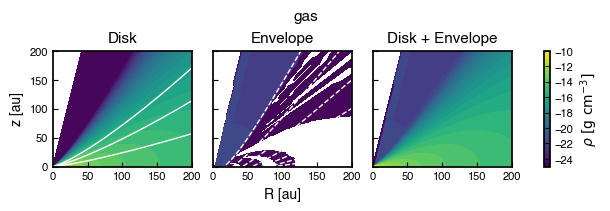

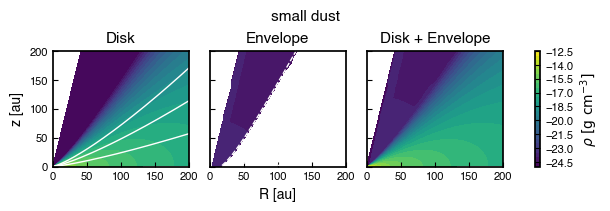

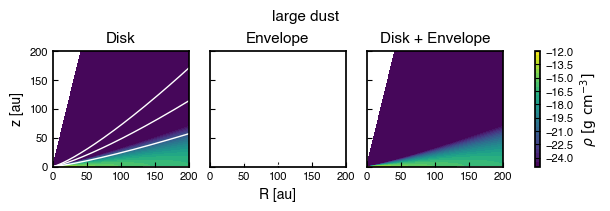

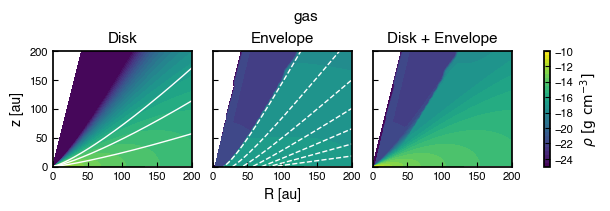

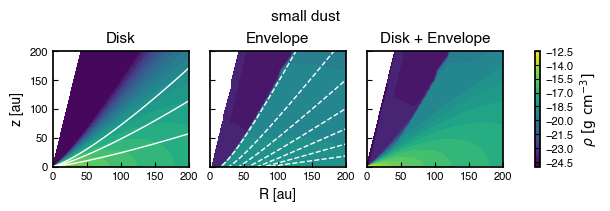

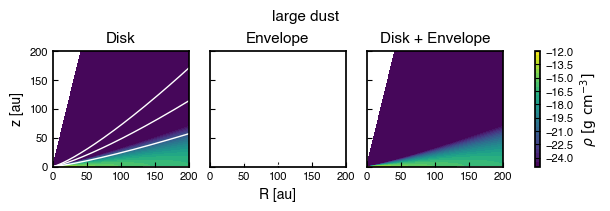

In [24]:
wedge.plot_components(fid1_m,fluid=0,rlim=200)
wedge.plot_components(fid1_m,fluid=1,rlim=200)
wedge.plot_components(fid1_m,fluid=2,rlim=200)

wedge.plot_components(fid2_m,fluid=0,rlim=200)
wedge.plot_components(fid2_m,fluid=1,rlim=200)
wedge.plot_components(fid2_m,fluid=2,rlim=200)

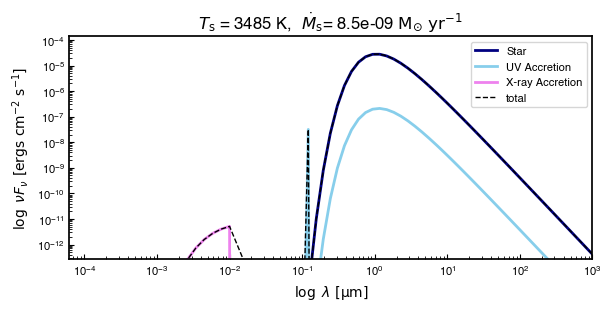

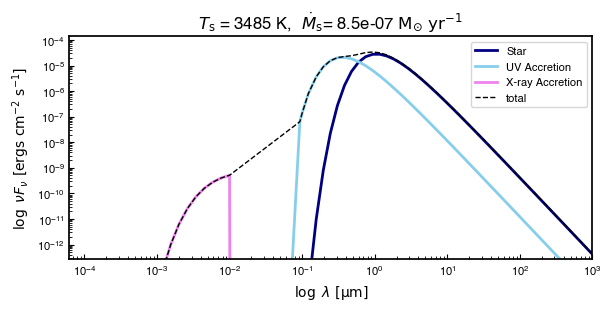

In [444]:
wedge.plot_flux_components(fid1_m)
wedge.plot_flux_components(fid2_m)

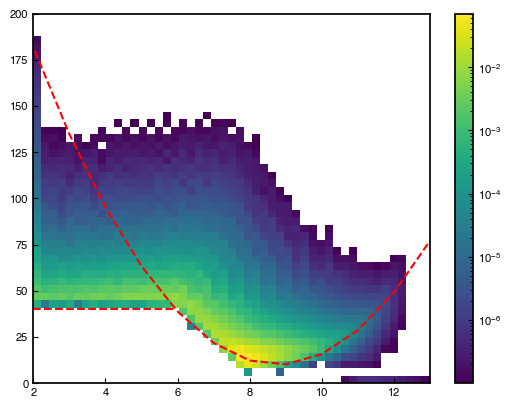

In [482]:
datay = fid1_T_components.ravel()
datax = np.log10(fid1_rho_gas_components.ravel()/1.67e-24)
w1 = fid1_m.m.dvol().swapaxes(0,1).ravel()
f, ax = plt.subplots(1)


def y(x):
    x=np.linspace(0,10)
    y=90*(x-1.79)**2 + 10
    return y

nbinsy=np.linspace(0,200,50)
nbinsx=np.linspace(2,13,50)
nbinsxy = [nbinsx,nbinsy]
hist = ax.hist2d(datax,datay,bins=nbinsxy, norm=LogNorm(),weights=w1, density=True, cmin=1e-7,cmax=1)
plt.colorbar(hist[3], ax=ax)
plt.axhline(y=40,xmin=0,xmax=.36, linestyle='--',color='r')
plt.plot(y(x),linestyle='--', color='r')

# h,x,y,m = hist
# plt.contour(x,y,h,levels=[1e-4,1e-3])
plt.show()

### ADD FUNCTION

In [206]:
w1 = fid1_m.m.dvol().swapaxes(0,1).ravel()
np.shape(w1)

(180, 90, 48)

In [440]:
np.shape(fid1_T_components)

(180, 90, 48)

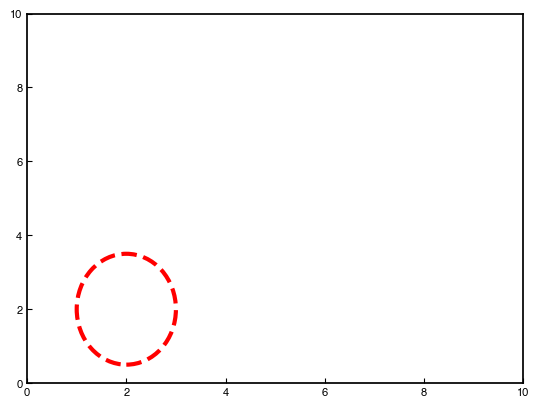

In [442]:
import matplotlib.patches as patches

f,ax = subplots(1)
ellipse=patches.Ellipse((2,2), 2, 3, linestyle='--', fill=False, ec='red', linewidth=3)
ax.add_patch(ellipse)
ax.set_xlim(0,10)
ax.set_ylim(0,10)
plt.show()

In [436]:
def fit_ellipse(h,k,w,l):
    fit_ellipse=ellipse=patches.Ellipse((h,k), w, l, linestyle='--', fill=False, ec='red', linewidth=3)
    ellipse = ax.add_patch(fit_ellipse)
    return ellipse

In [438]:
fit_ellipse(2,2,2,3)